In [53]:
import matplotlib.pyplot as plt
import plotly.express as pltexp
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder
labeller = LabelEncoder()

In [54]:
import klib

In [55]:
df = pd.read_csv(r"C:\Users\bunyo\OneDrive\Desktop\git_dataset\healthcare_dataset.csv")

In [56]:
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [57]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [58]:
klib.missingval_plot(df)

No missing values found in the dataset.


In [59]:
klib.corr_interactive_plot(df)

In [60]:
plt.figure(figsize=(8,6))
plt.hist(df['Vehicle Type'],bins=7,color='skyblue',edgecolor='black')
plt.title('Uberdagi foydalanilgan mashina turi')
plt.show()

KeyError: 'Vehicle Type'

<Figure size 800x600 with 0 Axes>

In [ ]:
def tozalovchi(df):
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype=='object':
                df[col].fillna(df[col].mode()[0],inplace=True)
            else:
                df[col].fillna(df[col].mean(),inplace=True)
    return df

In [ ]:
df = tozalovchi(df)

C:\Users\bunyo\AppData\Local\Temp\ipykernel_12372\523197141.py:7: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\bunyo\AppData\Local\Temp\ipykernel_12372\523197141.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  int64  
 1   Time                               150000 non-null  int64  
 2   Booking ID                         150000 non-null  int64  
 3   Booking Status                     150000 non-null  int64  
 4   Customer ID                        150000 non-null  int64  
 5   Vehicle Type                       150000 non-null  int64  
 6   Pickup Location                    150000 non-null  int64  
 7   Drop Location                      150000 non-null  int64  
 8   Avg VTAT                           150000 non-null  float64
 9   Avg CTAT                           150000 non-null  float64
 10  Cancelled Rides by Customer        150000 non-null  float64
 11  Reason for cancelling by Customer  1500

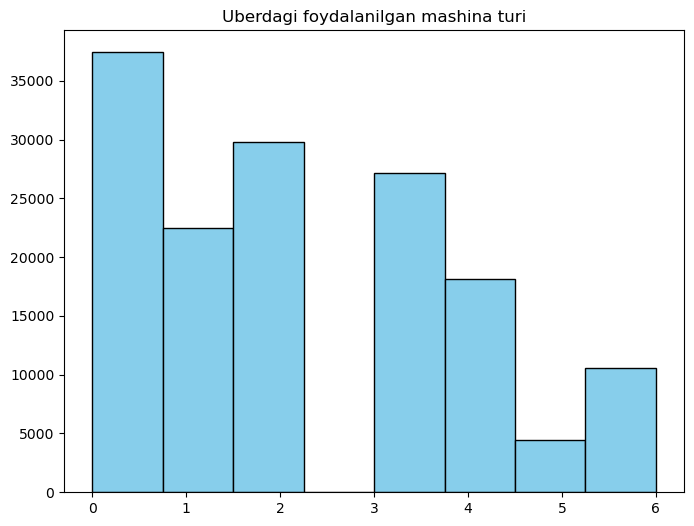

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(df['Vehicle Type'],bins=8,color='skyblue',edgecolor='black')
plt.title('Uberdagi foydalanilgan mashina turi')
plt.show()

In [ ]:
def encodla(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            if df[col].nunique() <= 4:
                dummies=pd.get_dummies(df[col],prefix=col,dtype=int)
                df=pd.concat([df.drop(columns=col),dummies],axis=1)
            else:
                df[col]=labeller.fit_transform(df[col])
    return df


In [ ]:
encodla(df)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Driver Ratings,Customer Rating,Payment Method,Driver Cancellation Reason_Customer related issue,Driver Cancellation Reason_More than permitted people in there,Driver Cancellation Reason_Personal & Car related issues,Driver Cancellation Reason_The customer was coughing/sick,Incomplete Rides Reason_Customer Demand,Incomplete Rides Reason_Other Issue,Incomplete Rides Reason_Vehicle Breakdown
0,82,27223,80398,4,16198,6,116,68,8.456352,29.149636,...,4.230992,4.404584,3,1,0,0,0,1,0,0
1,333,44812,5340,3,59522,3,149,47,4.900000,14.000000,...,4.230992,4.404584,3,1,0,0,0,0,0,1
2,235,15712,123807,2,135726,0,80,90,13.400000,25.800000,...,4.900000,4.900000,2,1,0,0,0,1,0,0
3,294,42274,130594,2,26449,4,21,60,13.100000,28.500000,...,4.600000,5.000000,3,1,0,0,0,1,0,0
4,259,58545,15756,2,147677,1,39,79,5.300000,19.600000,...,4.100000,4.300000,3,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,315,50165,90677,2,55079,2,87,38,10.200000,44.400000,...,3.700000,4.100000,4,1,0,0,0,1,0,0
149996,328,37652,24220,2,21809,2,40,2,5.100000,30.800000,...,4.800000,5.000000,3,1,0,0,0,1,0,0
149997,261,22196,88312,2,147560,3,146,69,2.700000,23.400000,...,3.900000,4.400000,0,1,0,0,0,1,0,0
149998,278,12552,33362,2,139126,0,37,140,6.900000,39.600000,...,4.100000,3.700000,3,1,0,0,0,1,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  int64  
 1   Time                               150000 non-null  int64  
 2   Booking ID                         150000 non-null  int64  
 3   Booking Status                     150000 non-null  int64  
 4   Customer ID                        150000 non-null  int64  
 5   Vehicle Type                       150000 non-null  int64  
 6   Pickup Location                    150000 non-null  int64  
 7   Drop Location                      150000 non-null  int64  
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1500

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  int64  
 1   Time                               150000 non-null  int64  
 2   Booking ID                         150000 non-null  int64  
 3   Booking Status                     150000 non-null  int64  
 4   Customer ID                        150000 non-null  int64  
 5   Vehicle Type                       150000 non-null  int64  
 6   Pickup Location                    150000 non-null  int64  
 7   Drop Location                      150000 non-null  int64  
 8   Avg VTAT                           150000 non-null  float64
 9   Avg CTAT                           150000 non-null  float64
 10  Cancelled Rides by Customer        150000 non-null  float64
 11  Reason for cancelling by Customer  1500

# Random forrest

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
DT_reg = DecisionTreeRegressor()

In [ ]:
x = df.drop('Ride Distance', axis=1)
y = df['Ride Distance']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=45)

In [ ]:
DT_reg.fit(x_train,y_train)

ValueError: could not convert string to float: 'Customer related issue'